# 01 - Segmentation Basics

**Goal:** Understand what image segmentation is and how it differs from classification.

---

## Classification vs Segmentation

| Task | Input | Output | Example |
|------|-------|--------|--------|
| **Classification** | Image | Single label | "This is a cat" |
| **Segmentation** | Image | Label per pixel | "These pixels are cat, these are background" |

Segmentation = **classification at every pixel**.

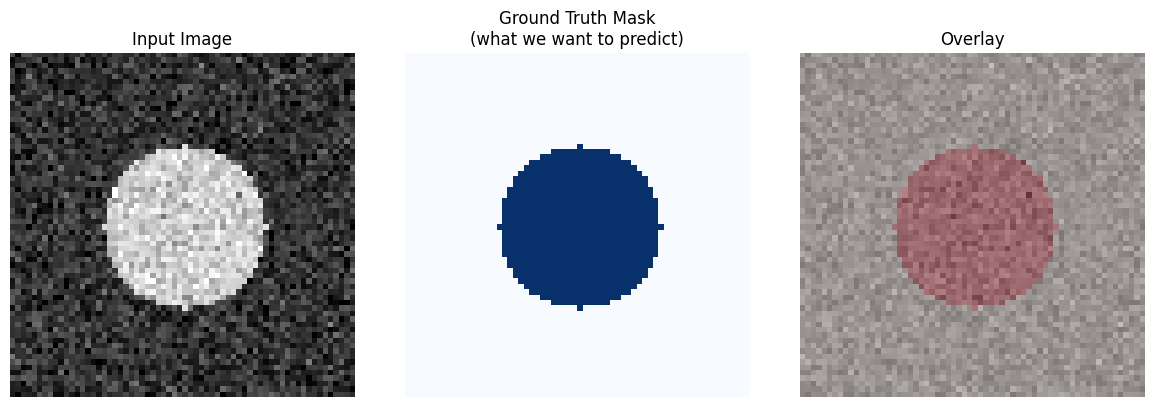

Image shape: (64, 64)
Mask shape: (64, 64)
Mask values: [0. 1.]


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Create a simple example
# Image with a circle we want to segment

def create_circle_image(size=64, radius=15, center=None):
    """Create an image with a circle."""
    if center is None:
        center = (size // 2, size // 2)
    
    y, x = np.ogrid[:size, :size]
    dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    
    # Image: circle is brighter
    image = np.where(dist <= radius, 0.8, 0.2).astype(np.float32)
    # Add noise
    image += np.random.normal(0, 0.1, image.shape).astype(np.float32)
    image = np.clip(image, 0, 1)
    
    # Mask: 1 inside circle, 0 outside
    mask = (dist <= radius).astype(np.float32)
    
    return image, mask

# Generate example
image, mask = create_circle_image()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Input Image')
axes[0].axis('off')

axes[1].imshow(mask, cmap='Blues')
axes[1].set_title('Ground Truth Mask\n(what we want to predict)')
axes[1].axis('off')

axes[2].imshow(image, cmap='gray')
axes[2].imshow(mask, cmap='Reds', alpha=0.5)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Mask values: {np.unique(mask)}")

## Types of Segmentation

| Type | Description | Example |
|------|-------------|--------|
| **Binary** | 2 classes (foreground/background) | Tumor vs no tumor |
| **Multi-class** | N classes, one per pixel | Vertebrae: C1, C2, ... L5, background |
| **Instance** | Separate objects of same class | "Vertebra 1", "Vertebra 2" (not just "vertebra") |

Your spine segmentation does **multi-class** (each vertebra type) + **instance** (individual vertebrae).

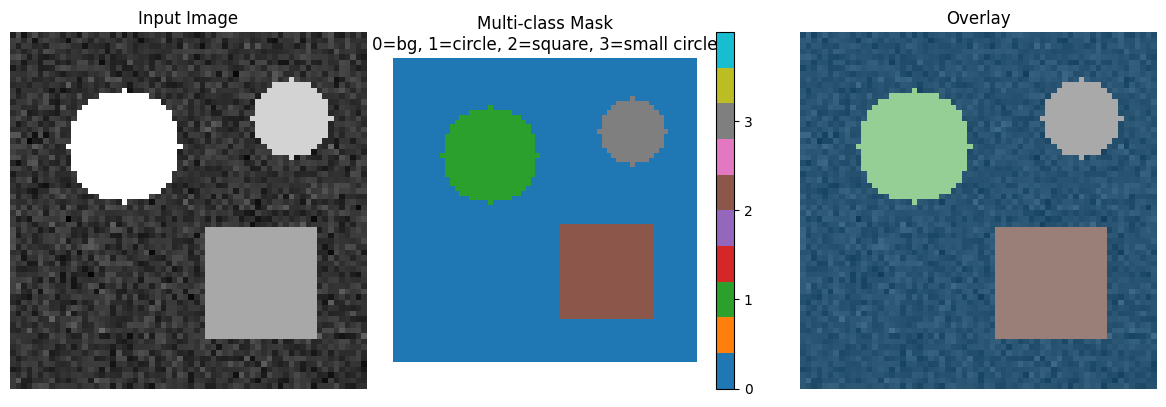

Classes in mask: [0 1 2 3]


In [2]:
# Multi-class example: multiple shapes

def create_multiclass_image(size=64):
    """Create image with circle, square, triangle."""
    image = np.random.normal(0.2, 0.05, (size, size)).astype(np.float32)
    mask = np.zeros((size, size), dtype=np.int64)
    
    # Circle (class 1)
    y, x = np.ogrid[:size, :size]
    circle = np.sqrt((x - 20)**2 + (y - 20)**2) <= 10
    image[circle] = 0.9
    mask[circle] = 1
    
    # Square (class 2)
    image[35:55, 35:55] = 0.6
    mask[35:55, 35:55] = 2
    
    # Small circle (class 3)
    small_circle = np.sqrt((x - 50)**2 + (y - 15)**2) <= 7
    image[small_circle] = 0.75
    mask[small_circle] = 3
    
    return np.clip(image, 0, 1), mask

image, mask = create_multiclass_image()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Input Image')
axes[0].axis('off')

im = axes[1].imshow(mask, cmap='tab10', vmin=0, vmax=4)
axes[1].set_title('Multi-class Mask\n0=bg, 1=circle, 2=square, 3=small circle')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], ticks=[0, 1, 2, 3])

axes[2].imshow(image, cmap='gray')
axes[2].imshow(mask, cmap='tab10', alpha=0.5, vmin=0, vmax=4)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Classes in mask: {np.unique(mask)}")

## Segmentation as Classification

For N classes, the model outputs N channels - one probability map per class:

```
Input:  (batch, 1, H, W)      # Grayscale image
Output: (batch, N, H, W)      # N probability maps
```

Then we take `argmax` across channels to get the final segmentation.

In [ ]:
# Simulate model output
H, W = 64, 64
num_classes = 4

# Fake model output: logits for each class
logits = torch.randn(1, num_classes, H, W)  # (batch, classes, H, W)

# Convert to probabilities
probs = torch.softmax(logits, dim=1)  # Sum to 1 across classes

# Get prediction: argmax across class dimension
prediction = logits.argmax(dim=1)  # (batch, H, W)

print(f"Logits shape: {logits.shape}")
print(f"Probabilities shape: {probs.shape}")
print(f"Prediction shape: {prediction.shape}")
print(f"\nAt pixel (0,0):")
print(f"  Logits: {logits[0, :, 0, 0].numpy()}")
print(f"  Probs:  {probs[0, :, 0, 0].numpy()} (sum={probs[0, :, 0, 0].sum():.2f})")
print(f"  Prediction: class {prediction[0, 0, 0].item()}")

In [ ]:
# Visualize probability maps
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(4):
    axes[i].imshow(probs[0, i].numpy(), cmap='hot', vmin=0, vmax=1)
    axes[i].set_title(f'P(class {i})')
    axes[i].axis('off')

axes[4].imshow(prediction[0].numpy(), cmap='tab10', vmin=0, vmax=4)
axes[4].set_title('Prediction (argmax)')
axes[4].axis('off')

plt.tight_layout()
plt.show()

## Loss Functions for Segmentation

### Cross-Entropy Loss
Same as classification, but computed per pixel.

### Dice Loss
Measures overlap between prediction and ground truth. Better for imbalanced classes (like medical imaging where background >> object).

In [ ]:
# Cross-Entropy Loss for segmentation

criterion = nn.CrossEntropyLoss()

# Fake prediction and target
pred = torch.randn(2, 4, 64, 64)  # batch=2, classes=4, 64x64
target = torch.randint(0, 4, (2, 64, 64))  # batch=2, 64x64 (class indices)

loss = criterion(pred, target)
print(f"Prediction shape: {pred.shape}")
print(f"Target shape: {target.shape}")
print(f"Cross-Entropy Loss: {loss.item():.4f}")

In [ ]:
# Dice Loss implementation

def dice_loss(pred, target, smooth=1e-6):
    """
    Dice Loss for binary segmentation.
    
    pred: (batch, H, W) - predicted probabilities (after sigmoid)
    target: (batch, H, W) - ground truth (0 or 1)
    """
    pred = pred.view(-1)
    target = target.view(-1)
    
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    
    return 1 - dice  # Loss = 1 - Dice coefficient

# Example
pred_probs = torch.sigmoid(torch.randn(1, 64, 64))
target_mask = (torch.rand(1, 64, 64) > 0.7).float()

loss = dice_loss(pred_probs, target_mask)
print(f"Dice Loss: {loss.item():.4f}")
print(f"Dice Coefficient: {1 - loss.item():.4f}")

## Why Dice Loss for Medical Imaging?

Medical images often have **class imbalance**:
- Background: 95% of pixels
- Tumor/organ: 5% of pixels

Cross-entropy treats all pixels equally → model can get 95% accuracy by predicting all background!

Dice focuses on **overlap** → forces model to find the object.

In [ ]:
# Demonstrate class imbalance problem

# Ground truth: small object (5% of image)
target = torch.zeros(1, 64, 64)
target[0, 28:36, 28:36] = 1  # 8x8 = 64 pixels out of 4096 = 1.5%

# Prediction 1: All background (lazy model)
pred_all_bg = torch.zeros(1, 64, 64)

# Prediction 2: Perfect prediction
pred_perfect = target.clone()

# Prediction 3: Partial overlap
pred_partial = torch.zeros(1, 64, 64)
pred_partial[0, 30:38, 30:38] = 1

print("Pixel-wise accuracy (misleading for imbalanced data):")
print(f"  All background: {(pred_all_bg == target).float().mean():.2%}")
print(f"  Perfect: {(pred_perfect == target).float().mean():.2%}")
print(f"  Partial: {(pred_partial == target).float().mean():.2%}")

print("\nDice coefficient (better metric):")
print(f"  All background: {1 - dice_loss(pred_all_bg, target).item():.2%}")
print(f"  Perfect: {1 - dice_loss(pred_perfect, target).item():.2%}")
print(f"  Partial: {1 - dice_loss(pred_partial, target).item():.2%}")

## The Architecture Challenge

Classification CNNs:
- Progressively downsample (pool)
- End with global average pool + dense layer
- Output: single vector

Segmentation needs:
- Same spatial resolution as input
- Dense prediction (every pixel)

**Solution: Encoder-Decoder architecture**

```
Encoder: Image → compressed features (downsample)
Decoder: Compressed features → full resolution (upsample)
```

But simple upsampling loses detail. **U-Net** solves this with skip connections.

In [ ]:
# Simple encoder (like classification CNN)
encoder = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),  # 64 -> 32
    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),  # 32 -> 16
)

# Problem: how to get back to 64x64?
x = torch.randn(1, 1, 64, 64)
encoded = encoder(x)
print(f"Input: {x.shape}")
print(f"After encoder: {encoded.shape}")
print("\nWe need to get back to 64x64 for segmentation!")

In [ ]:
# Upsampling options

# Option 1: Bilinear interpolation
upsample_bilinear = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

# Option 2: Transposed convolution (learnable upsampling)
upsample_conv = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)

small = torch.randn(1, 64, 16, 16)
print(f"Input: {small.shape}")
print(f"After bilinear upsample: {upsample_bilinear(small).shape}")
print(f"After transposed conv: {upsample_conv(small).shape}")

## Summary

| Concept | What it means |
|---------|---------------|
| **Segmentation** | Classify every pixel (dense prediction) |
| **Mask** | Ground truth labels for each pixel |
| **Multi-class** | Multiple classes (vertebrae types, organs) |
| **Output shape** | (batch, num_classes, H, W) |
| **Dice Loss** | Measures overlap, handles class imbalance |
| **Encoder-Decoder** | Downsample then upsample |

**Next:** U-Net architecture - the standard for medical image segmentation.